In [ ]:
import os

from RNAFoldAssess.models.scorers import EternaScorer


path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_data/inputs/eterna_data.csv"

with open(path) as fh:
    data = fh.readlines()

data.pop(0)
data = [d.split(",") for d in data]

for i, x in enumerate(data[0]):
    print(f"{i} {x}")


def normalize_reactivities(score_block):
    pairs = score_block.strip().split(";")
    new_pairs = []
    for p in pairs:
        index, score = p.split(":")
        index = int(index)
        score = float(score)
        if score >= 0:
            new_pairs.append([index, score])

    if len(new_pairs) == 0:
        return False
    highest = max([s[1] for s in new_pairs])
    if highest == 0:
        return False
    for p in new_pairs:
        p[1] /= highest

    return new_pairs

def relative_seq_pos(seq, score_block):
    positions = [s[0] for s in score_block]
    relative_sequence = "".join([seq[i] for i in positions])
    reactivities = [s[1] for s in score_block]
    return relative_sequence, reactivities

In [ ]:
model_preds = {}
for f in os.listdir("/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_data/outputs"):
    with open(f"/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_data/outputs/{f}") as fh:
        pred_data = fh.readlines()
    model = f.split("_")[0]
    model_preds[model] = {}
    pred_data = [pd.split(", ") for pd in pred_data]
    for pd in pred_data:
        dp = pd[1]
        pred = pd[3]
        auroc_score = pd[4]
        model_preds[model][dp] = {"prediction": pred, "auroc": auroc_score}

all_models = list(model_preds.keys())
model_scores = {}
for m in all_models:
    model_scores[m] = {}

unpaired_values = [i / 100 for i in range(0, 100, 1)]
paired_values = [i / 100 for i in range(0, 100, 1)]

threshold_pairs = [
    (unpaired_threshold, paired_threshold)
    for unpaired_threshold in unpaired_values
    for paired_threshold in paired_values
    if paired_threshold <= unpaired_threshold - 0.10
]

In [ ]:
model_preds["SPOT-RNA"]

In [ ]:
counter = 0
data_len = len(data)

for dd in data:
    counter += 1
    if counter % 813 == 0:
        print(f"Working {counter} of {data_len}")
    try:
        dp = dd[0]
        seq = dd[1]
        kind = dd[2]
        reactivity_block = normalize_reactivities(dd[3])
        if not reactivity_block:
            continue
        relative_seq, reactivities = relative_seq_pos(seq, reactivity_block)
        positions = [r[0] for r in reactivity_block]
        for m in all_models:
            if dp not in model_preds[m]:
                continue
            pred = model_preds[m][dp]["prediction"]
            relative_pred = "".join([pred[p] for p in positions])
            # breakpoint()
            for unpaired_threshold, paired_threshold in threshold_pairs:
                try:
                    eterna_score = EternaScorer.score(
                        relative_seq,
                        relative_pred,
                        reactivities,
                        unpaired_threshold=unpaired_threshold,
                        paired_threshold=paired_threshold,
                        experiment_type=kind.upper()
                    )

                    column_name = (
                        f"eterna_"
                        f"{unpaired_threshold:.2f}_"
                        f"{paired_threshold:.2f}"
                    )

                    model_preds[m][dp][column_name] = eterna_score

                except Exception as e:
                    fails += 1
                    continue
        churn += 1
    except Exception as e:
        continue




In [ ]:
model_preds["SPOT-RNA"]["ETERNA_R00_0000_ANNOTATION_175"]

In [ ]:
import csv

def write_results_to_csv(results, output_path):
    # ------------------------------------------------------------
    # First pass: collect all score columns
    # ------------------------------------------------------------
    score_columns = set()

    for model_name, datapoints in results.items():
        for datapoint_name, score_data in datapoints.items():
            for key in score_data.keys():
                if key != "prediction":
                    score_columns.add(key)

    # Optional: sort columns for stable output
    score_columns = sorted(score_columns)

    fieldnames = ["model", "datapoint"] + score_columns

    # ------------------------------------------------------------
    # Second pass: stream rows directly to CSV
    # ------------------------------------------------------------
    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=fieldnames,
            extrasaction="ignore"
        )

        writer.writeheader()

        for model_name, datapoints in results.items():
            for datapoint_name, score_data in datapoints.items():
                row = {
                    "model": model_name,
                    "datapoint": datapoint_name,
                }

                for key, value in score_data.items():
                    if key != "prediction":
                        row[key] = value

                writer.writerow(row)

In [ ]:
write_results_to_csv(model_preds, "eterna_with_thresholds_and_auroc5.csv")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = pd.read_csv("eterna_with_thresholds_and_auroc5.csv")
df

,model,datapoint,auroc,eterna_0.10_0.00,eterna_0.11_0.00,eterna_0.12_0.00,eterna_0.12_0.01,eterna_0.13_0.00,eterna_0.13_0.01,eterna_0.13_0.02,...,eterna_0.99_0.80,eterna_0.99_0.81,eterna_0.99_0.82,eterna_0.99_0.83,eterna_0.99_0.84,eterna_0.99_0.85,eterna_0.99_0.86,eterna_0.99_0.87,eterna_0.99_0.88,eterna_0.99_0.89
0,NeuralFold,ETOBCR_VN1_0001_ANNOTATION_1,0.556452,0.031746,0.031746,0.031746,0.063492,0.031746,0.063492,0.222222,...,0.428571,0.428571,0.428571,0.428571,0.428571,0.428571,0.428571,0.428571,0.428571,0.428571
1,NeuralFold,ETOBCR_VN1_0001_ANNOTATION_2,0.543011,0.090909,0.090909,0.075758,0.075758,0.075758,0.075758,0.121212,...,0.439394,0.439394,0.439394,0.439394,0.439394,0.439394,0.439394,0.439394,0.439394,0.439394
2,NeuralFold,ETOBCR_VN1_0001_ANNOTATION_3,0.582437,0.333333,0.333333,0.333333,0.349206,0.301587,0.317460,0.349206,...,0.539683,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556
3,NeuralFold,ETOBCR_VN1_0001_ANNOTATION_4,0.573925,0.323077,0.307692,0.292308,0.292308,0.276923,0.276923,0.292308,...,0.538462,0.538462,0.538462,0.538462,0.538462,0.538462,0.538462,0.538462,0.538462,0.538462
4,NeuralFold,ETOBCR_VN1_0001_ANNOTATION_5,0.672460,0.305085,0.305085,0.288136,0.389831,0.271186,0.372881,0.423729,...,0.491525,0.491525,0.491525,0.491525,0.491525,0.491525,0.491525,0.491525,0.491525,0.491525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505916,Simfold,ETERNA_R41_0001_ANNOTATION_16,0.660428,0.164557,0.151899,0.126582,0.227848,0.126582,0.227848,0.316456,...,0.518987,0.518987,0.518987,0.518987,0.518987,0.518987,0.518987,0.518987,0.518987,0.518987
505917,Simfold,ETERNA_R41_0001_ANNOTATION_17,0.626114,0.229885,0.206897,0.195402,0.218391,0.195402,0.218391,0.264368,...,0.528736,0.528736,0.528736,0.528736,0.528736,0.528736,0.528736,0.528736,0.528736,0.528736
505918,Simfold,ETERNA_R41_0001_ANNOTATION_18,0.651515,0.235955,0.202247,0.191011,0.202247,0.179775,0.191011,0.247191,...,0.539326,0.539326,0.539326,0.539326,0.539326,0.539326,0.539326,0.539326,0.539326,0.539326
505919,Simfold,ETERNA_R41_0001_ANNOTATION_19,0.762478,0.163043,0.119565,0.108696,0.184783,0.108696,0.184783,0.282609,...,0.510870,0.510870,0.510870,0.510870,0.510870,0.510870,0.510870,0.510870,0.510870,0.510870


In [2]:
df.shape

(505921, 4085)

In [3]:
for c in df.columns.to_list():
    if "eterna_" not in c:
        continue
    _, unpaired_threshold, paired_threshold = c.split("_")
    if paired_threshold == "0.20":
        print(c)

eterna_0.31_0.20
eterna_0.32_0.20
eterna_0.33_0.20
eterna_0.34_0.20
eterna_0.35_0.20
eterna_0.36_0.20
eterna_0.37_0.20
eterna_0.38_0.20
eterna_0.39_0.20
eterna_0.40_0.20
eterna_0.41_0.20
eterna_0.42_0.20
eterna_0.43_0.20
eterna_0.44_0.20
eterna_0.45_0.20
eterna_0.46_0.20
eterna_0.47_0.20
eterna_0.48_0.20
eterna_0.49_0.20
eterna_0.50_0.20
eterna_0.51_0.20
eterna_0.52_0.20
eterna_0.53_0.20
eterna_0.54_0.20
eterna_0.55_0.20
eterna_0.56_0.20
eterna_0.57_0.20
eterna_0.58_0.20
eterna_0.59_0.20
eterna_0.60_0.20
eterna_0.61_0.20
eterna_0.62_0.20
eterna_0.63_0.20
eterna_0.64_0.20
eterna_0.65_0.20
eterna_0.66_0.20
eterna_0.67_0.20
eterna_0.68_0.20
eterna_0.69_0.20
eterna_0.70_0.20
eterna_0.71_0.20
eterna_0.72_0.20
eterna_0.73_0.20
eterna_0.74_0.20
eterna_0.75_0.20
eterna_0.76_0.20
eterna_0.77_0.20
eterna_0.78_0.20
eterna_0.79_0.20
eterna_0.80_0.20
eterna_0.81_0.20
eterna_0.82_0.20
eterna_0.83_0.20
eterna_0.84_0.20
eterna_0.85_0.20
eterna_0.86_0.20
eterna_0.87_0.20
eterna_0.88_0.20
eterna_0.89_0.

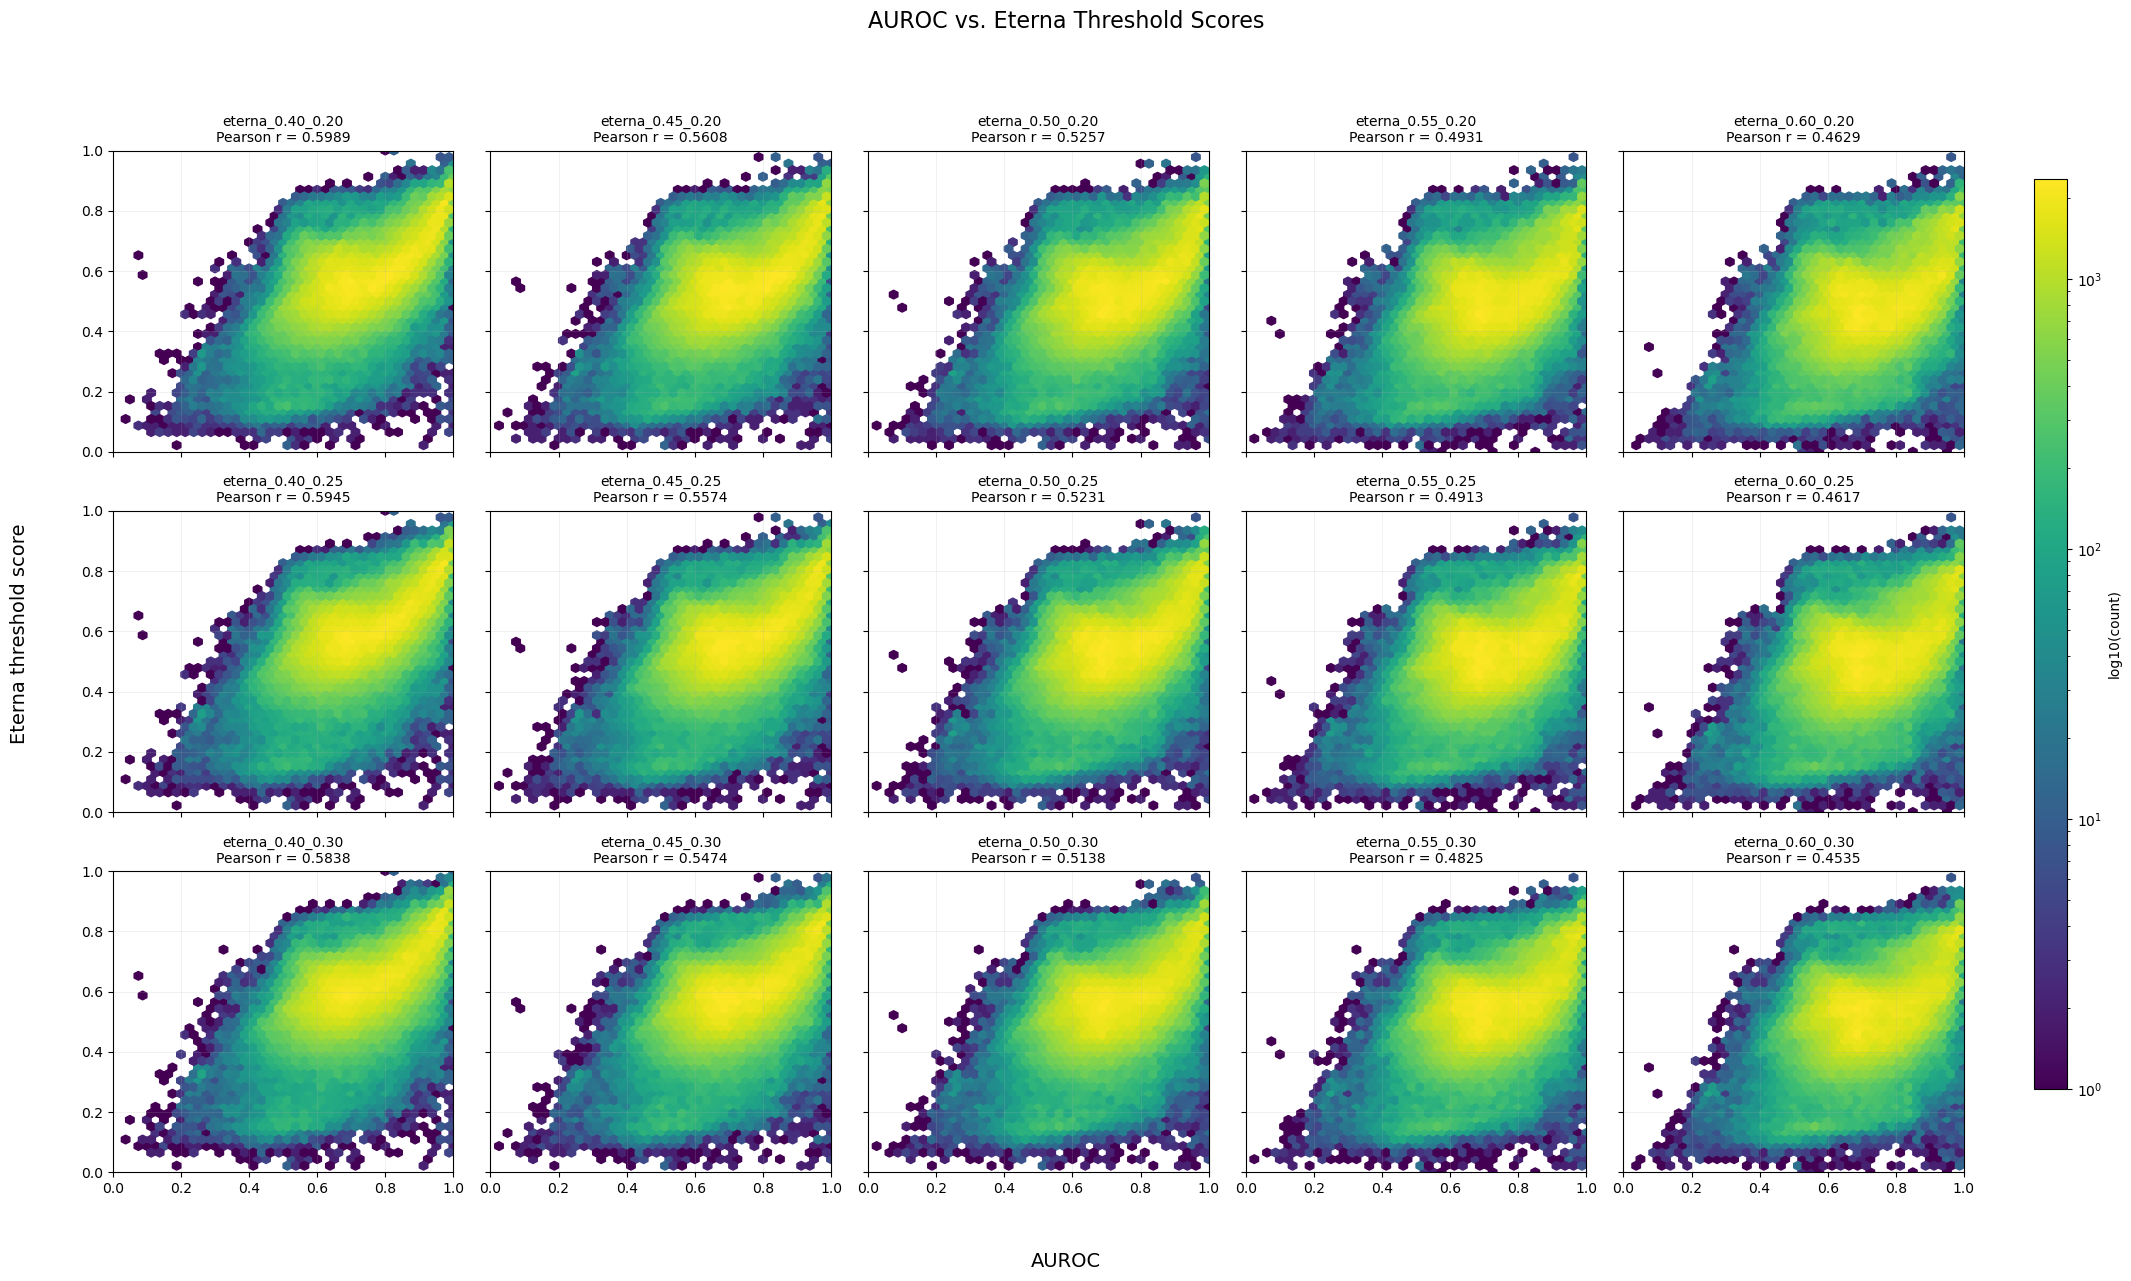

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import math

cols_to_plot = [
    "eterna_0.40_0.20",
    "eterna_0.45_0.20",
    "eterna_0.50_0.20",
    "eterna_0.55_0.20",
    "eterna_0.60_0.20",
    "eterna_0.40_0.25",
    "eterna_0.45_0.25",
    "eterna_0.50_0.25",
    "eterna_0.55_0.25",
    "eterna_0.60_0.25",
    "eterna_0.40_0.30",
    "eterna_0.45_0.30",
    "eterna_0.50_0.30",
    "eterna_0.55_0.30",
    "eterna_0.60_0.30",
]

n_rows = 3
n_cols = 5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 13),
    squeeze=False,
    sharex=True,
    sharey=True
)

axes_flat = axes.flatten()

hb = None

for ax, col in zip(axes_flat, cols_to_plot):
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in df")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        r = float("nan")
    else:
        r, _ = pearsonr(sub["auroc"], sub[col])

    hb = ax.hexbin(
        sub["auroc"],
        sub[col],
        gridsize=40,
        extent=(0, 1, 0, 1),
        mincnt=1,
        bins="log"
    )

    ax.set_title(f"{col}\nPearson r = {r:.4f}", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, linewidth=0.5)

# Shared axis labels
fig.supxlabel("AUROC", fontsize=14)
fig.supylabel("Eterna threshold score", fontsize=14)

fig.suptitle(
    "AUROC vs. Eterna Threshold Scores",
    fontsize=16,
    y=0.98
)

# Leave room on the right for the colorbar
plt.tight_layout(rect=[0.03, 0.03, 0.92, 0.94])

# Manually pin colorbar to the right side
# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.70])

cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("log10(count)")

plt.savefig(
    "auroc_vs_eterna_hexbin_grid_3x5_eterna_only.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

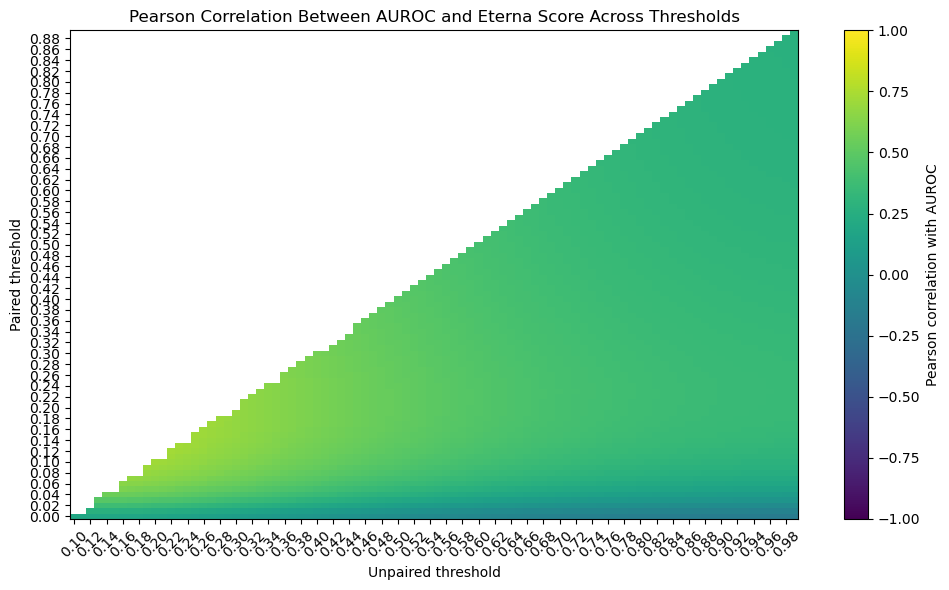

In [6]:
threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in threshold_cols:
    # Example: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        pearson_corr = None
    else:
        pearson_corr, _ = pearsonr(sub["auroc"], sub[col])

    rows.append({
        "unpaired_threshold": float(unpaired_threshold),
        "paired_threshold": float(paired_threshold),
        "pearson_corr": pearson_corr,
    })

corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="pearson_corr"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson correlation with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("Pearson Correlation Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_pearson_heatmap_all.png", dpi=500)
plt.show()

In [11]:
for c in df.columns.to_list():
    if "eterna_" not in c:
        continue
    _, unpaired_threshold, paired_threshold = c.split("_")
    if paired_threshold in ["0.12", "0.13", "0.14"]:
        print(c)

eterna_0.22_0.12
eterna_0.23_0.12
eterna_0.23_0.13
eterna_0.24_0.12
eterna_0.24_0.13
eterna_0.25_0.12
eterna_0.25_0.13
eterna_0.25_0.14
eterna_0.26_0.12
eterna_0.26_0.13
eterna_0.26_0.14
eterna_0.27_0.12
eterna_0.27_0.13
eterna_0.27_0.14
eterna_0.28_0.12
eterna_0.28_0.13
eterna_0.28_0.14
eterna_0.29_0.12
eterna_0.29_0.13
eterna_0.29_0.14
eterna_0.30_0.12
eterna_0.30_0.13
eterna_0.30_0.14
eterna_0.31_0.12
eterna_0.31_0.13
eterna_0.31_0.14
eterna_0.32_0.12
eterna_0.32_0.13
eterna_0.32_0.14
eterna_0.33_0.12
eterna_0.33_0.13
eterna_0.33_0.14
eterna_0.34_0.12
eterna_0.34_0.13
eterna_0.34_0.14
eterna_0.35_0.12
eterna_0.35_0.13
eterna_0.35_0.14
eterna_0.36_0.12
eterna_0.36_0.13
eterna_0.36_0.14
eterna_0.37_0.12
eterna_0.37_0.13
eterna_0.37_0.14
eterna_0.38_0.12
eterna_0.38_0.13
eterna_0.38_0.14
eterna_0.39_0.12
eterna_0.39_0.13
eterna_0.39_0.14
eterna_0.40_0.12
eterna_0.40_0.13
eterna_0.40_0.14
eterna_0.41_0.12
eterna_0.41_0.13
eterna_0.41_0.14
eterna_0.42_0.12
eterna_0.42_0.13
eterna_0.42_0.

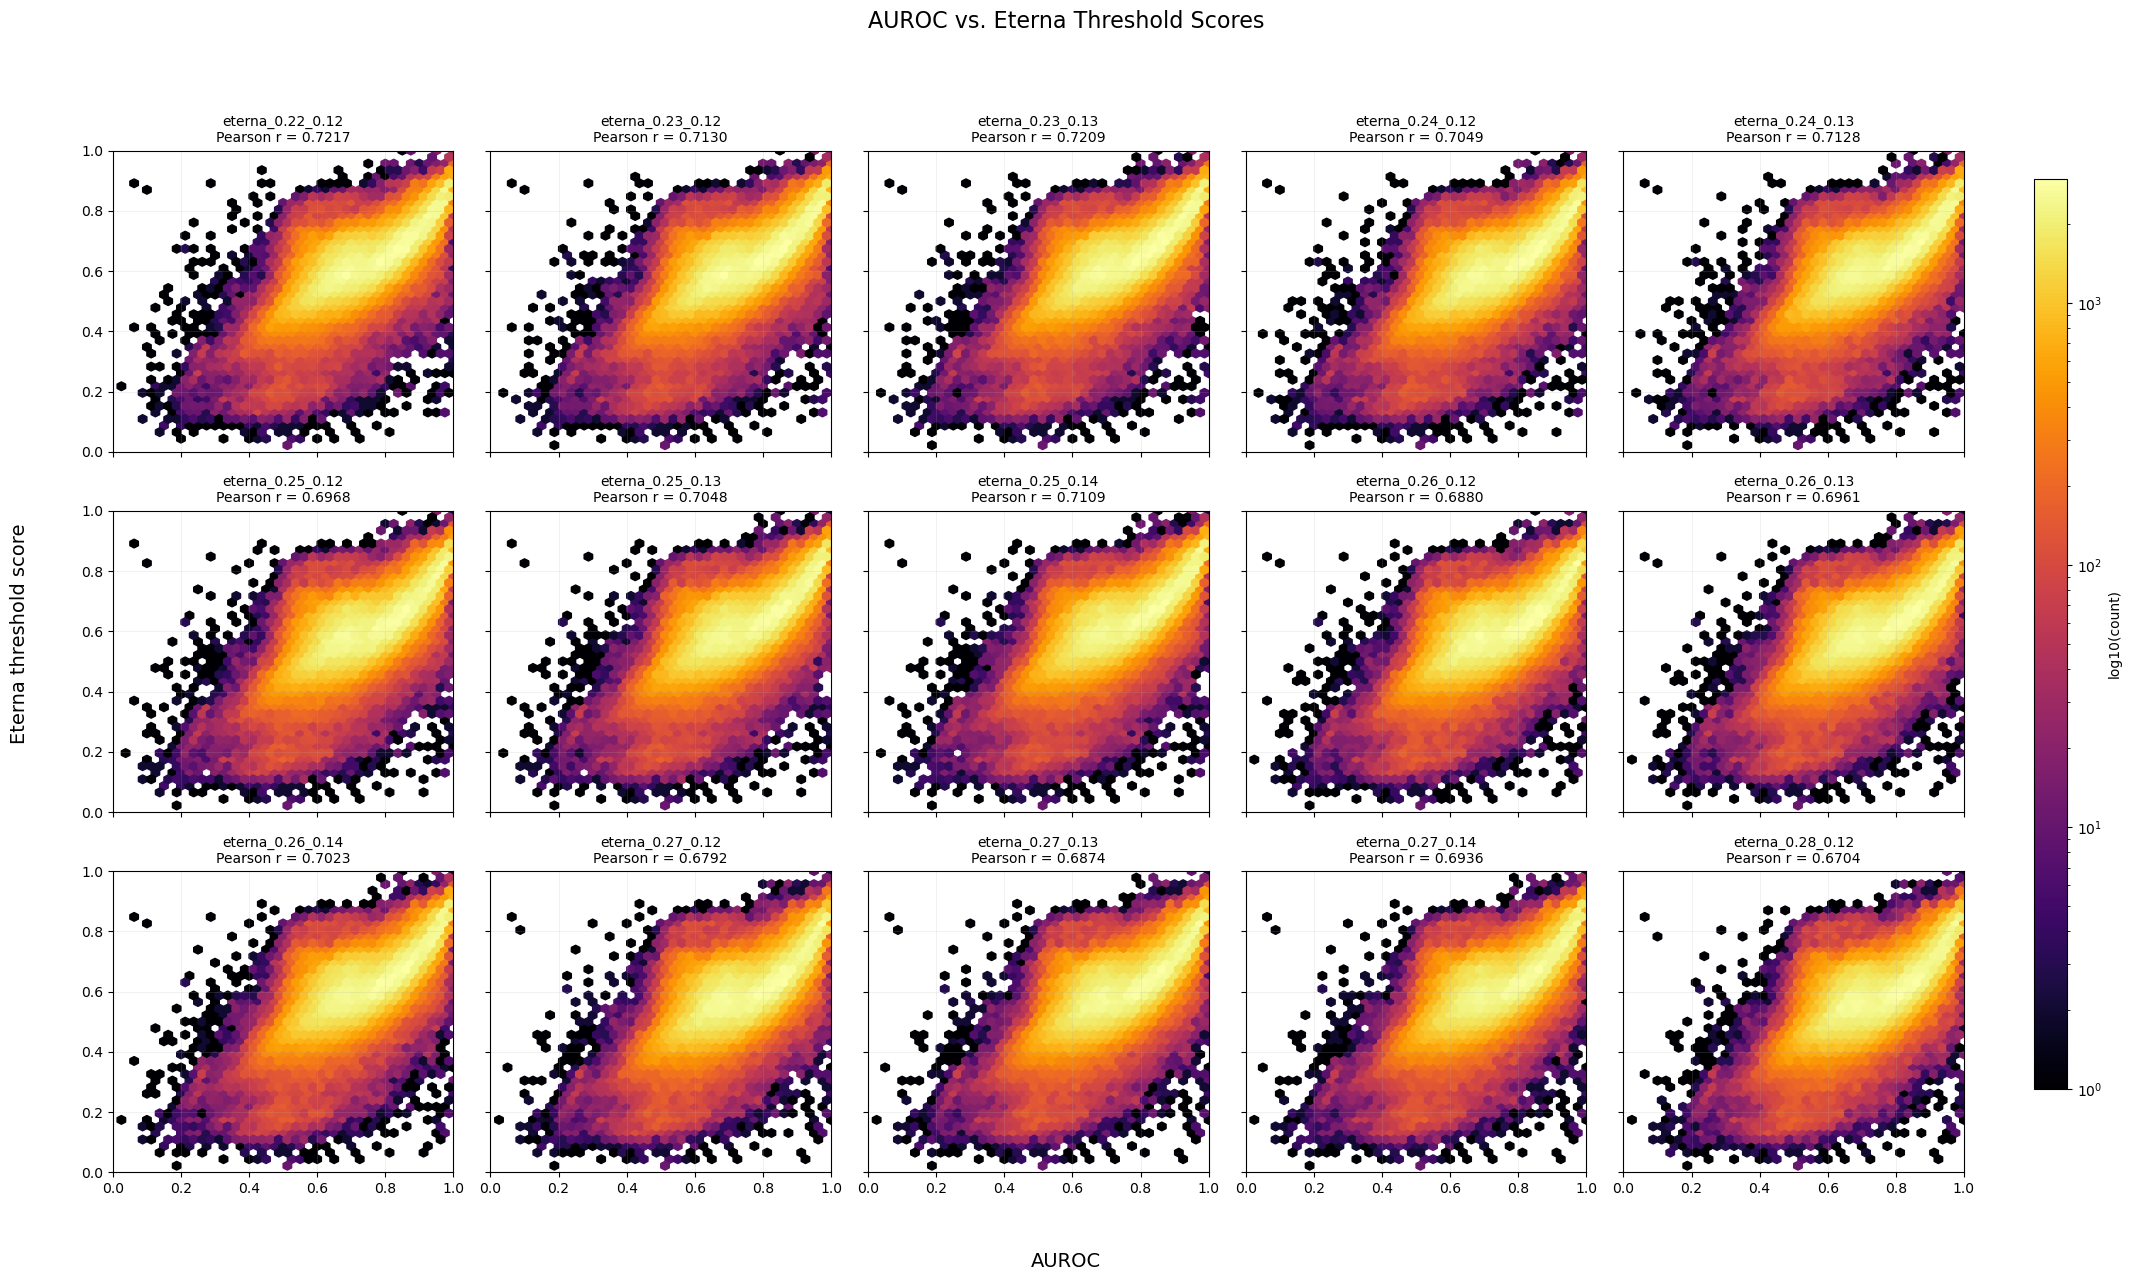

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import math

cols_to_plot = [
    "eterna_0.22_0.12",
    "eterna_0.23_0.12",
    "eterna_0.23_0.13",
    "eterna_0.24_0.12",
    "eterna_0.24_0.13",
    "eterna_0.25_0.12",
    "eterna_0.25_0.13",
    "eterna_0.25_0.14",
    "eterna_0.26_0.12",
    "eterna_0.26_0.13",
    "eterna_0.26_0.14",
    "eterna_0.27_0.12",
    "eterna_0.27_0.13",
    "eterna_0.27_0.14",
    "eterna_0.28_0.12",
]

n_rows = 3
n_cols = 5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 13),
    squeeze=False,
    sharex=True,
    sharey=True
)

axes_flat = axes.flatten()

hb = None

for ax, col in zip(axes_flat, cols_to_plot):
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in df")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        r = float("nan")
    else:
        r, _ = pearsonr(sub["auroc"], sub[col])

    hb = ax.hexbin(
        sub["auroc"],
        sub[col],
        gridsize=40,
        extent=(0, 1, 0, 1),
        mincnt=1,
        bins="log",
        cmap="inferno"
    )

    ax.set_title(f"{col}\nPearson r = {r:.4f}", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, linewidth=0.5)

# Shared axis labels
fig.supxlabel("AUROC", fontsize=14)
fig.supylabel("Eterna threshold score", fontsize=14)

fig.suptitle(
    "AUROC vs. Eterna Threshold Scores",
    fontsize=16,
    y=0.98
)

# Leave room on the right for the colorbar
plt.tight_layout(rect=[0.03, 0.03, 0.92, 0.94])

# Manually pin colorbar to the right side
# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.70])

cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("log10(count)")

plt.savefig(
    "auroc_vs_eterna_hexbin_grid_3x5_eterna_only2.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

In [13]:
import pandas as pd
from scipy.stats import pearsonr

eterna_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in eterna_cols:
    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        r = float("nan")
        p_value = float("nan")
    else:
        r, p_value = pearsonr(sub["auroc"], sub[col])

    rows.append({
        "column": col,
        "pearson_r": r,
        "p_value": p_value,
        "n": len(sub),
    })

corr_df = pd.DataFrame(rows)

top_15 = (
    corr_df
    .sort_values("pearson_r", ascending=False)
    .head(15)
)

top_15

,column,pearson_r,p_value,n
85,eterna_0.22_0.12,0.721673,0.0,467974
99,eterna_0.23_0.13,0.720878,0.0,467974
129,eterna_0.25_0.15,0.715831,0.0,467974
61,eterna_0.20_0.10,0.714153,0.0,467974
98,eterna_0.23_0.12,0.712957,0.0,467974
113,eterna_0.24_0.13,0.712807,0.0,467974
84,eterna_0.22_0.11,0.711266,0.0,467974
128,eterna_0.25_0.14,0.710857,0.0,467974
146,eterna_0.26_0.16,0.710560,0.0,467974
145,eterna_0.26_0.15,0.707265,0.0,467974


In [14]:
top_15["column"].to_list()

['eterna_0.22_0.12',
 'eterna_0.23_0.13',
 'eterna_0.25_0.15',
 'eterna_0.20_0.10',
 'eterna_0.23_0.12',
 'eterna_0.24_0.13',
 'eterna_0.22_0.11',
 'eterna_0.25_0.14',
 'eterna_0.26_0.16',
 'eterna_0.26_0.15',
 'eterna_0.21_0.10',
 'eterna_0.19_0.09',
 'eterna_0.24_0.12',
 'eterna_0.25_0.13',
 'eterna_0.27_0.17']

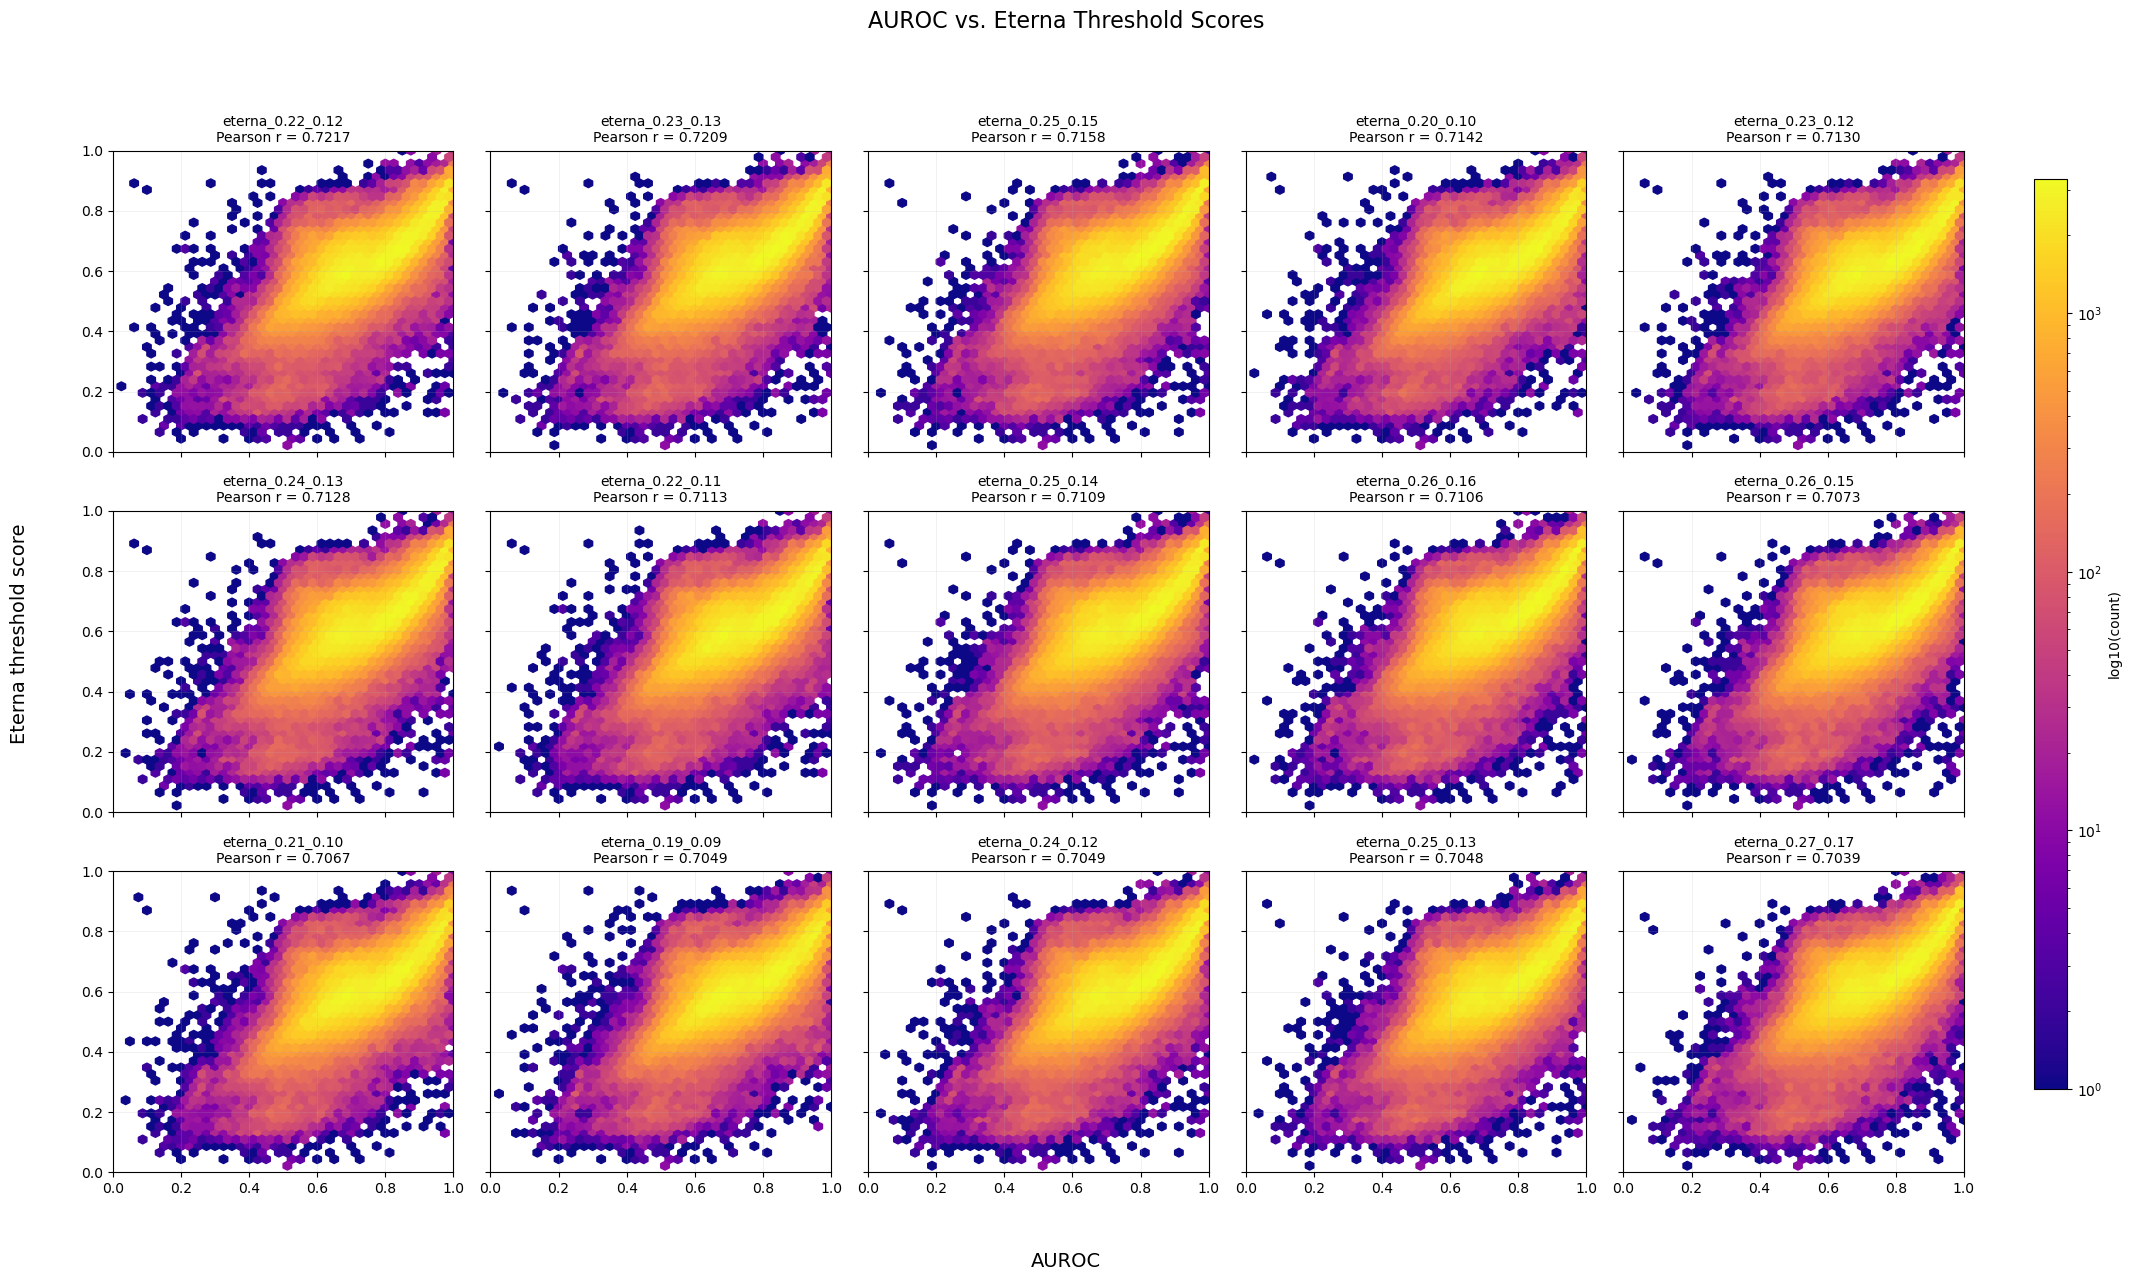

In [17]:
cols_to_plot = ['eterna_0.22_0.12',
 'eterna_0.23_0.13',
 'eterna_0.25_0.15',
 'eterna_0.20_0.10',
 'eterna_0.23_0.12',
 'eterna_0.24_0.13',
 'eterna_0.22_0.11',
 'eterna_0.25_0.14',
 'eterna_0.26_0.16',
 'eterna_0.26_0.15',
 'eterna_0.21_0.10',
 'eterna_0.19_0.09',
 'eterna_0.24_0.12',
 'eterna_0.25_0.13',
 'eterna_0.27_0.17']

n_rows = 3
n_cols = 5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 13),
    squeeze=False,
    sharex=True,
    sharey=True
)

axes_flat = axes.flatten()

hb = None

for ax, col in zip(axes_flat, cols_to_plot):
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in df")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        r = float("nan")
    else:
        r, _ = pearsonr(sub["auroc"], sub[col])

    hb = ax.hexbin(
        sub["auroc"],
        sub[col],
        gridsize=40,
        extent=(0, 1, 0, 1),
        mincnt=1,
        bins="log",
        cmap="plasma"
    )

    ax.set_title(f"{col}\nPearson r = {r:.4f}", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, linewidth=0.5)

# Shared axis labels
fig.supxlabel("AUROC", fontsize=14)
fig.supylabel("Eterna threshold score", fontsize=14)

fig.suptitle(
    "AUROC vs. Eterna Threshold Scores",
    fontsize=16,
    y=0.98
)

# Leave room on the right for the colorbar
plt.tight_layout(rect=[0.03, 0.03, 0.92, 0.94])

# Manually pin colorbar to the right side
# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.70])

cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("log10(count)")

plt.savefig(
    "auroc_vs_eterna_hexbin_grid_3x5_eterna_only_best.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()


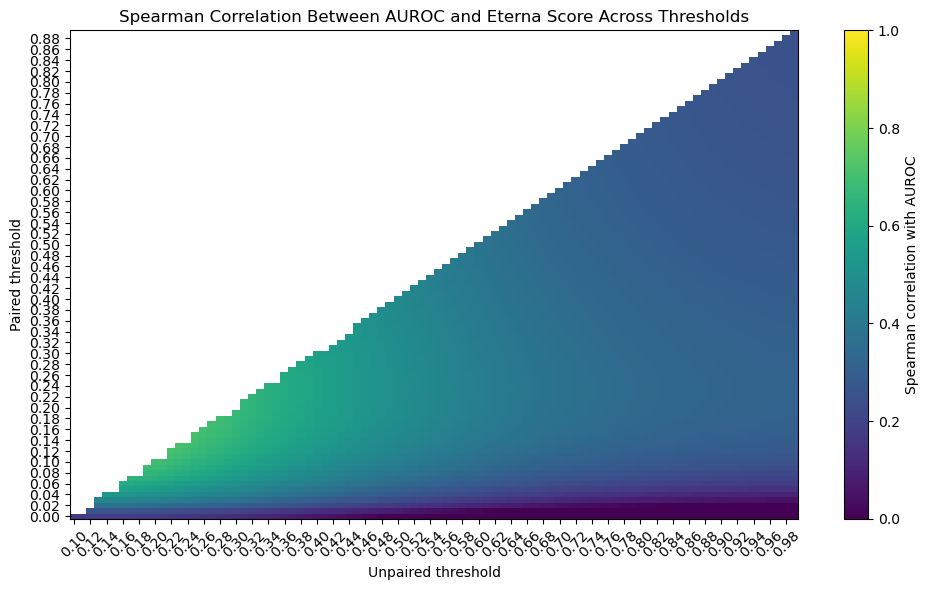

In [20]:
from scipy.stats import spearmanr

threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in threshold_cols:
    # Example: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        spearman_r2 = None
        r2 = None
    else:
        spearman_corr, _ = spearmanr(sub["auroc"], sub[col])
        pearson_corr, _ = pearsonr(sub["auroc"], sub[col])
        r2 = pearson_corr ** 2

    rows.append({
        "unpaired_threshold": float(unpaired_threshold),
        "paired_threshold": float(paired_threshold),
        "spearman_corr": spearman_corr,
        "r2": r2
    })

corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="spearman_corr"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Spearman correlation with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("Spearman Correlation Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_spearman_r2_heatmap_all.png", dpi=500)
plt.show()

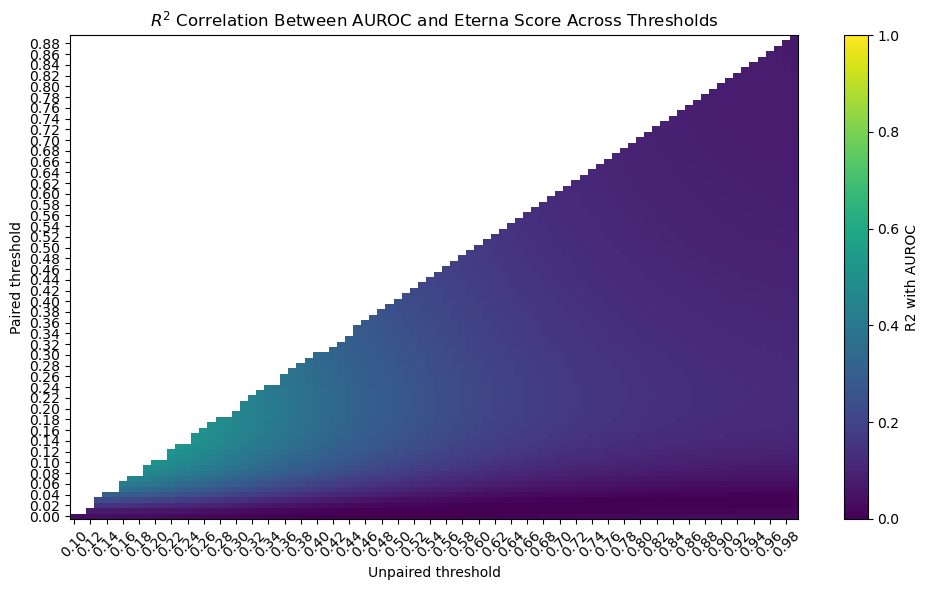

In [21]:
corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="r2"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.colorbar(label="R2 with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("$R^2$ Correlation Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_r2_heatmap_all.png", dpi=500)
plt.show()

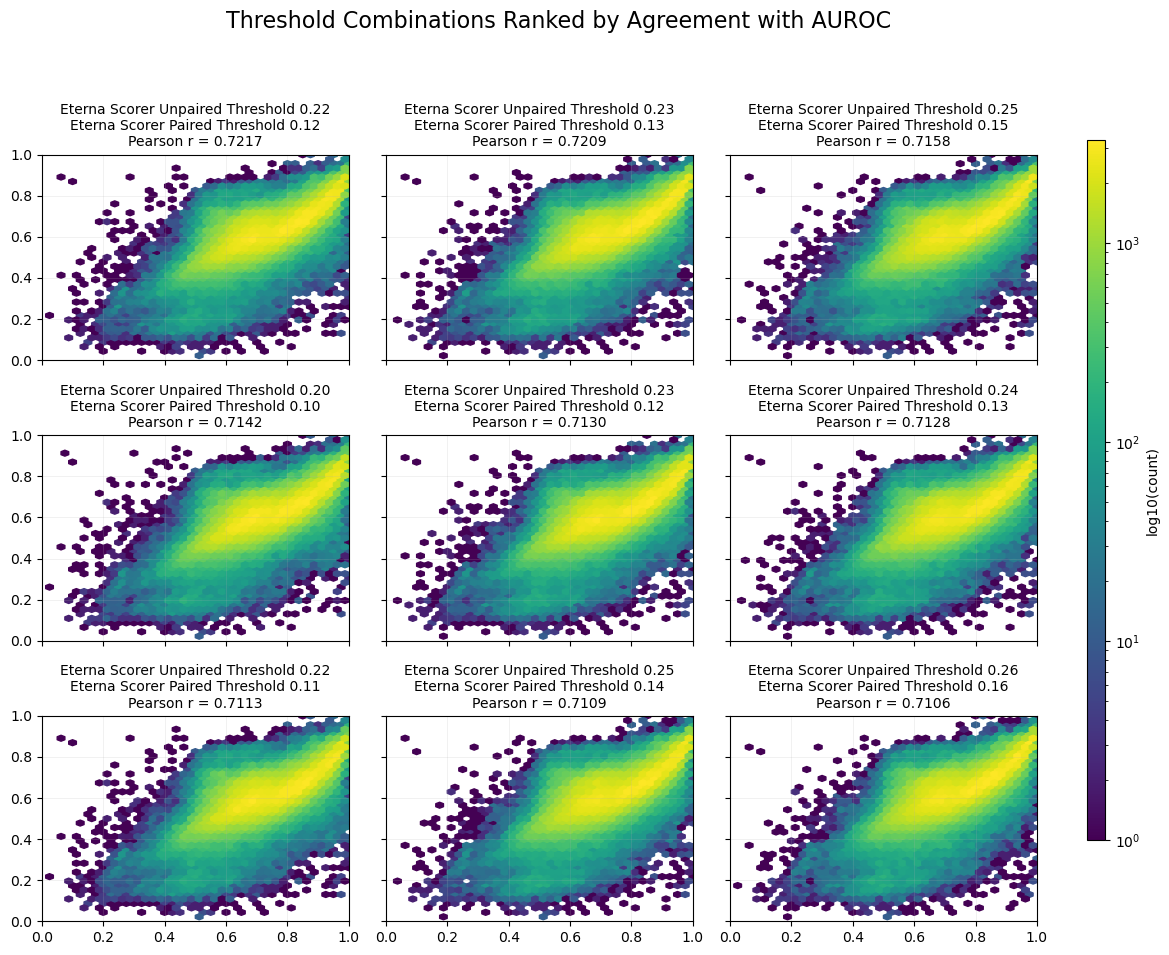

In [30]:
def col_to_title(col_name):
    _, unpaired_threshold, paired_threshold = col_name.split("_")
    title = f"Eterna Scorer Unpaired Threshold {unpaired_threshold}\nEterna Scorer Paired Threshold {paired_threshold}"
    return title


cols_to_plot = ['eterna_0.22_0.12',
 'eterna_0.23_0.13',
 'eterna_0.25_0.15',
 'eterna_0.20_0.10',
 'eterna_0.23_0.12',
 'eterna_0.24_0.13',
 'eterna_0.22_0.11',
 'eterna_0.25_0.14',
 'eterna_0.26_0.16',]

n_rows = 3
n_cols = 3

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 10),
    squeeze=False,
    sharex=True,
    sharey=True
)

axes_flat = axes.flatten()

hb = None

for ax, col in zip(axes_flat, cols_to_plot):
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in df")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        r = float("nan")
    else:
        r, _ = pearsonr(sub["auroc"], sub[col])

    hb = ax.hexbin(
        sub["auroc"],
        sub[col],
        gridsize=40,
        extent=(0, 1, 0, 1),
        mincnt=1,
        bins="log"
    )

    ax.set_title(f"{col_to_title(col)}\nPearson r = {r:.4f}", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, linewidth=0.5)

# Shared axis labels
# fig.supxlabel("AUROC", fontsize=14)
# fig.supylabel("Eterna threshold score", fontsize=14)

fig.suptitle(
    "Threshold Combinations Ranked by Agreement with AUROC",
    fontsize=16,
    y=0.98
)

# Leave room on the right for the colorbar
plt.tight_layout(rect=[0.03, 0.03, 0.92, 0.94])

# Manually pin colorbar to the right side
# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.70])

cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("log10(count)")

plt.savefig(
    "auroc_vs_eterna_hexbin_grid_3x3_eterna_only_best.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()
